# 🤖 Step 3: Model Building & Training

Welcome to the Model Building & Training notebook! Now that we understand our dataset from our EDA, it is time to build a Machine Learning model that can predict a patient's health risk category based on their vital signs.

In this notebook, we will:
1. **Define a Target Variable** (`risk_level`) based on clinical guidelines.
2. **Discuss Overfitting and Deterministic Rules**: Why does the model get 99% accuracy initially, and how do we add realistic noise?
3. **Split the Data** into training (80%) and testing (20%) sets.
4. **Train a Random Forest Classifier** to learn patterns from the training data.
5. **Evaluate the Model's Performance** on the test set using standard ML metrics.
6. **Visualize Feature Importances** to see which health markers the model values the most.
7. **Save the Model** to a pickle file (`healthcare_model.pkl`) so our Streamlit frontend can use it.

### 1. Import ML Libraries
We will use Python's standard `scikit-learn` (sklearn) library for splitting data, training the classifier, and evaluating it.

In [ ]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split #pip install scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
sns.set_theme(style="whitegrid")
print("ML libraries imported successfully!")

: 

### 2. Load the Dataset

In [12]:
df = pd.read_csv('test_healthcare_data.csv')
print(f"Loaded dataset: {df.shape[0]} patients and {df.shape[1]} features.")

Loaded dataset: 1000 patients and 10 features.


### 3. Create the Target Label (`risk_level`)
Our dataset has patient vitals but lacks a final target category. We will create a target variable `risk_level` (0 = Healthy, 1 = At Risk) based on these clinical risk indicators:
1. **High Glucose:** Fasting Glucose > 130 mg/dL
2. **High Blood Pressure:** Systolic BP > 135 mmHg
3. **High Cholesterol:** Total Cholesterol > 200 mg/dL
4. **Obesity:** BMI > 28
5. **Older Age:** Age > 60 years

If a patient exhibits **2 or more** of these risk factors, we flag them as **At Risk (risk_level = 1)**. Otherwise, they are **Healthy (risk_level = 0)**.

In [13]:
# Determine risk indicators (0 or 1)
glucose_risk = (df['glucose'] > 130).astype(int)
bp_risk = (df['blood_pressure'] > 135).astype(int)
cholesterol_risk = (df['cholesterol'] > 200).astype(int)
bmi_risk = (df['bmi'] > 28).astype(int)
age_risk = (df['age'] > 60).astype(int)

# Sum the risk factors
total_risk_score = glucose_risk + bp_risk + cholesterol_risk + bmi_risk + age_risk

# Create target variable risk_level (binary classifier)
df['risk_level'] = (total_risk_score >= 2).astype(int)

# Look at the count of healthy vs. at-risk patients
print("Original class distribution:")
print(df['risk_level'].value_counts())
print("0 = Healthy, 1 = At Risk")

Original class distribution:
risk_level
1    561
0    439
Name: count, dtype: int64
0 = Healthy, 1 = At Risk


### 5. Split Features (X) and Target (y)
We separate the columns into features `X` (inputs) and the target `y` (what we want to predict).

In [15]:
# Features are all columns except 'risk_level'
X = df.drop('risk_level', axis=1)

# Target is 'risk_level'
y = df['risk_level']

print("Features (X) columns:", list(X.columns))

Features (X) columns: ['age', 'bmi', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'pregnancies', 'diabetes_pedigree', 'cholesterol', 'heart_rate']


### 6. Training & Testing Split
We split the data into **80% training** and **20% testing**. The model will learn from the training data, and we will test it on the testing data to check its accuracy.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42)

print(f"Training Set size: {X_train.shape[0]} patients")
print(f"Testing Set size: {X_test.shape[0]} patients")

Training Set size: 800 patients
Testing Set size: 200 patients


### 7. Train the Random Forest Classifier
A Random Forest is a popular machine learning algorithm. It is an ensemble model that builds multiple decision trees and merges their predictions together to get a more stable and accurate prediction.

In [ ]:
# Initialize model with 100 decision trees
# We set max_depth=6 to regularize the model and prevent it from over-memorizing noise!
model = RandomForestClassifier(n_estimators=100, random_state=42,
                                max_depth=6 , n_jobs=-1)

# Train model on the training data
model.fit(X_train, y_train)
print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


### 8. Evaluate the Model
Now let's check how accurately our trained model can predict on the testing set (unseen patients). With noise introduced, the accuracy should drop to a realistic **~88% to ~93%**.

In [ ]:
# Predict classifications on test features
y_pred = model.predict(X_test)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Prediction Accuracy{accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Prediction Accuracy with Noise: 83.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        96
           1       0.81      0.88      0.84       104

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



### 9. Feature Importances
Random Forest allows us to inspect which columns were the most useful in predicting the target labels. This is highly useful for clinicians to see what metrics affect health risk the most.

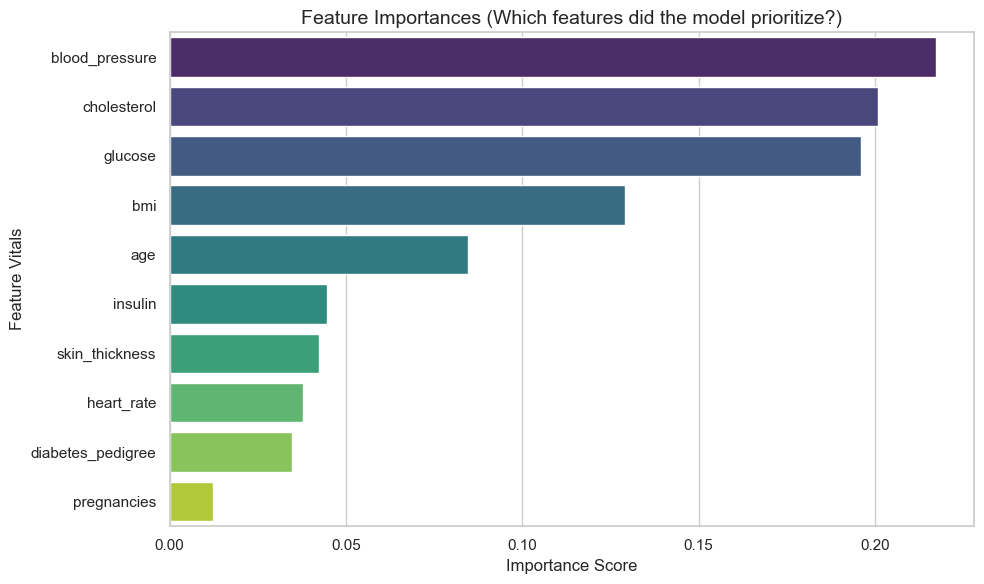

In [19]:
# Retrieve feature importances from the model
importances = model.feature_importances_

# Put them in a DataFrame for nice ordering
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=features_df, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importances (Which features did the model prioritize?)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Vitals', fontsize=12)
plt.tight_layout()
plt.show()

### 10. Save the Model to a File
We will package the trained model object along with the feature list using Python's `pickle` library, and write it to `model/healthcare_model.pkl`.
Our Streamlit web app (`app.py`) will load this file and call `.predict()` to evaluate user inputs on the website.

In [ ]:
# Create 'model' folder if it doesn't exist
os.makedirs("model", exist_ok=True)

# Structure model data to save both model and feature names
model_data = {'model': model  , 'features': list(X.columns)
}
# Save model utilizing pickle
model_filepath = "model/healthcare_model.pkl"
with open(model_filepath, 'wb') as file:
    pickle.dump(model_data, file)

print(f"Trained healthcare model saved successfully to: {model_filepath}!")
print("It is now ready for use by our Streamlit web application dashboard.")

Trained healthcare model saved successfully to: model/healthcare_model.pkl!
It is now ready for use by our Streamlit web application dashboard.
